<a href="https://colab.research.google.com/github/acg12/ml_projects/blob/main/Chatbot/NLP_Project_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup Environment

In [ ]:
!pip install tensorflow

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import json
import random
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import load_model

In [ ]:
nltk.download(['wordnet', 'punkt', 'omw-1.4'])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
lemmatizer = WordNetLemmatizer()

# !wget https://raw.githubusercontent.com/acg12/ml_projects/main/Intelligent%20AI%20Chatbot/intents.json
!wget https://raw.githubusercontent.com/acg12/ml_projects/main/Intelligent%20AI%20Chatbot/intents2.json

intents = json.loads(open('intents2.json').read())

--2022-06-21 05:51:59--  https://raw.githubusercontent.com/acg12/ml_projects/main/Intelligent%20AI%20Chatbot/intents2.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3162 (3.1K) [text/plain]
Saving to: ‘intents2.json.1’

intents2.json.1     100%[===================>]   3.09K  --.-KB/s    in 0s      

2022-06-21 05:51:59 (35.4 MB/s) - ‘intents2.json.1’ saved [3162/3162]



In [ ]:
words = []
classes = []
documents = []
ignore_letters = ['?', '!', '.', ',', "'"]

for intent in intents['intents']:
    for pattern in intent['patterns']:
        word_list = nltk.word_tokenize(pattern)
        words.extend(word_list)
        documents.append((word_list, intent['tag']))
        if intent['tag'] not in classes:
            classes.append(intent['tag'])

print(words)
print(classes)
print(documents)

['Hi', 'there', 'anyone', 'here', '?', 'hey', 'hola', 'Good', 'day', 'Hello', 'Hi', 'What', 'can', 'you', 'do', '?', 'Hi', ',', 'can', 'you', 'help', 'me', '?', 'I', 'need', 'help', 'can', 'you', 'assist', 'me', '?', 'What', 'can', 'I', 'do', '?', 'Thank', 'you', 'for', 'your', 'help', 'Thanks', 'for', 'helping', 'Thank', 'you', 'for', 'your', 'assistance', 'Thank', 'you', 'I', 'appreciate', 'it', 'Appreciate', 'for', 'your', 'help', 'What', 'do', 'you', 'sell', '?', 'What', 'do', 'you', 'offer', '?', 'All', 'products', 'What', 'are', 'your', 'products', '?', 'Can', 'I', 'see', 'your', 'products', '?', 'What', 'can', 'I', 'buy', '?', 'What', 'are', 'you', 'selling', 'here', '?', 'How', 'to', 'order', '?', 'Are', 'you', 'on', 'Shopee', '?', 'Are', 'you', 'on', 'Tokopedia', '?', 'How', 'can', 'I', 'order', '?', 'Do', 'you', 'have', 'offline', 'shop', '?', 'Where', 'can', 'I', 'buy', 'that', '?', 'What', 'platforms', 'are', 'you', 'on', '?', 'I', 'want', 'to', 'place', 'a', 'complaint', '

In [ ]:
words = [lemmatizer.lemmatize(word.lower()) for word in words if word not in ignore_letters]
words = sorted(set(words))
classes = sorted(set(classes))

pickle.dump(words, open('words.pkl', 'wb'))
pickle.dump(classes, open('classes.pkl', 'wb'))

In [ ]:
training = []
output_empty = np.zeros(len(classes))

for document in documents:
    bag = []
    word_patterns = document[0]
    word_patterns = [lemmatizer.lemmatize(word.lower()) for word in word_patterns]

    for word in words:
        bag.append(1) if word in word_patterns else bag.append(0)

    output_row = list(output_empty)
    output_row[classes.index(document[1])] = 1
    training.append([bag, output_row])

random.shuffle(training)
training = np.array(training)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:17: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


In [ ]:
training_data = []
training_data.append({"class":"greeting", "sentence":"how are you?"})
training_data.append({"class":"greeting", "sentence":"how is your day?"})
training_data.append({"class":"greeting", "sentence":"good day"})
training_data.append({"class":"greeting", "sentence":"how is it going today?"})

training_data.append({"class":"goodbye", "sentence":"have a nice day"})
training_data.append({"class":"goodbye", "sentence":"see you later"})
training_data.append({"class":"goodbye", "sentence":"have a nice day"})
training_data.append({"class":"goodbye", "sentence":"talk to you soon"})

training_data.append({"class":"sandwich", "sentence":"make me a sandwich"})
training_data.append({"class":"sandwich", "sentence":"can you make a sandwich?"})
training_data.append({"class":"sandwich", "sentence":"having a sandwich today?"})
training_data.append({"class":"sandwich", "sentence":"what's for lunch?"})

pd.DataFrame(training_data)

,class,sentence
0,greeting,how are you?
1,greeting,how is your day?
2,greeting,good day
3,greeting,how is it going today?
4,goodbye,have a nice day
5,goodbye,see you later
6,goodbye,have a nice day
7,goodbye,talk to you soon
8,sandwich,make me a sandwich
9,sandwich,can you make a sandwich?


In [ ]:
X = list(training[:, 0])
y = list(training[:, 1])
X_train = X[:40]
X_test = X[40:]
y_train = y[:40]
y_test = y[40:]

In [ ]:
model = Sequential()
model.add(Dense(128, input_shape=(len(X[0]),), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(y[0]), activation='softmax'))

In [ ]:
sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

In [ ]:
history = model.fit(np.array(X_train), np.array(y_train), epochs=100, batch_size=5, verbose=True)

Epoch 1/100
8/8 [==============================] - 1s 3ms/step - loss: 2.2281 - accuracy: 0.1250
Epoch 2/100
8/8 [==============================] - 0s 2ms/step - loss: 2.2240 - accuracy: 0.1000
Epoch 3/100
8/8 [==============================] - 0s 3ms/step - loss: 2.0737 - accuracy: 0.2750
Epoch 4/100
8/8 [==============================] - 0s 2ms/step - loss: 2.0241 - accuracy: 0.2750
Epoch 5/100
8/8 [==============================] - 0s 2ms/step - loss: 1.9793 - accuracy: 0.4000
Epoch 6/100
8/8 [==============================] - 0s 3ms/step - loss: 1.9213 - accuracy: 0.3500
Epoch 7/100
8/8 [==============================] - 0s 2ms/step - loss: 1.8705 - accuracy: 0.4250
Epoch 8/100
8/8 [==============================] - 0s 2ms/step - loss: 1.7279 - accuracy: 0.4500
Epoch 9/100
8/8 [==============================] - 0s 3ms/step - loss: 1.6193 - accuracy: 0.4750
Epoch 10/100
8/8 [==============================] - 0s 3ms/step - loss: 1.5335 - accuracy: 0.5500
Epoch 11/100
8/8 [===========

In [ ]:
model.save('chatbot_model.h5', history)

In [ ]:
def translate(y_list):
  res = []
  for y in y_list:
    res.append(np.argsort(y)[0])
  return res

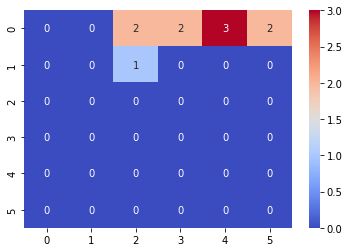

In [ ]:
y_pred = model.predict(np.array(X_test))
y_pred_tr = translate(y_pred)
y_test_tr = translate(y_test)
sns.heatmap(confusion_matrix(y_test_tr, y_pred_tr), cmap='coolwarm', annot=True)
plt.show()

In [ ]:
print(classification_report(y_test_tr, y_pred_tr, zero_division=True))

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       9.0
           1       1.00      0.00      0.00       1.0
           2       0.00      1.00      0.00       0.0
           3       0.00      1.00      0.00       0.0
           5       0.00      1.00      0.00       0.0
           7       0.00      1.00      0.00       0.0

    accuracy                           0.00      10.0
   macro avg       0.33      0.67      0.00      10.0
weighted avg       1.00      0.00      0.00      10.0



In [ ]:
accuracy_score(y_test_tr, y_pred_tr)

0.0

# ChatBot Interface

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
intents = json.loads(open('intents2.json').read())

In [ ]:
words = pickle.load(open('words.pkl', 'rb'))
print(words)
classes = pickle.load(open('classes.pkl', 'rb'))
print(classes)

["'d", 'a', 'about', 'all', 'am', 'any', 'anyone', 'appreciate', 'are', 'arrive', 'assist', 'assistance', 'buy', 'can', 'complain', 'complaint', 'day', 'discount', 'do', 'file', 'for', 'get', 'good', 'have', 'hello', 'help', 'helping', 'here', 'hey', 'hi', 'hola', 'how', 'i', 'is', 'it', 'like', 'make', 'me', 'my', 'need', 'not', 'of', 'offer', 'offline', 'on', 'order', 'place', 'platform', 'please', 'product', 'promos', 'promotion', 'refund', 'satisfied', 'see', 'sell', 'selling', 'shipment', 'shop', 'shopee', 'show', 'so', 'status', 'thank', 'thanks', 'that', 'the', 'there', 'to', 'today', 'tokopedia', 'track', 'want', 'way', 'what', 'when', 'where', 'will', 'wish', 'would', 'you', 'your']
['ask_platform', 'ask_products', 'complain', 'greetings', 'intro', 'promo', 'refund', 'thanks', 'tracking']


In [ ]:
model = load_model('chatbot_model.h5')

In [ ]:
def clean_input(input):
  inp_words = nltk.word_tokenize(input)
  inp_words = [lemmatizer.lemmatize(word.lower()) for word in inp_words]
  return inp_words

In [ ]:
def get_bow(sentence):
  sentence_words = clean_input(sentence)
  bag = np.zeros(len(words))

  for word in sentence_words:
    for i, w in enumerate(words):
      if w == word:
        bag[i] = 1

  return np.array(bag)

In [ ]:
def predict_intents(input):
  bow = get_bow(input)
  res = model.predict(np.array([bow]))[0]

  results = [[i, r] for i, r in enumerate(res) if r > 0.25]
  results.sort(key=lambda x: x[1], reverse=True)

  results_list = []
  for i in results:
    results_list.append({'intent': classes[i[0]], 'probability': str(i[1])})
  return results_list

In [ ]:
def get_response(pred_intents, intents_json):
  tag = pred_intents[0]['intent']
  intents = intents_json['intents']
  response = ""
  for i in intents:
    if i['tag'] == tag:
      response = random.choice(i['responses'])
      break
  return response

In [ ]:
while True:
  msg = input("Type 'quit' to leave > ")
  if msg == "quit":
      break
  pred_intents = predict_intents(msg)
  response = get_response(pred_intents, intents)
  print(response)

Type 'quit' to leave > hello
im here, how can i help you
Type 'quit' to leave > can i order
You can find us an place an order on Shopee, Tokopedia, and Lazada at @ElectroCartMax.
Type 'quit' to leave > can i order something?
You can find us an place an order on Shopee, Tokopedia, and Lazada at @ElectroCartMax.
Type 'quit' to leave > track my shipment
Here are the list of the product that are still on the way
Type 'quit' to leave > i want to file a complaint
We're so sorry hear that. Please follow the instructions to place a formal complaint.
Type 'quit' to leave > thanks
Glad I could help, please ask if you need anything else
Type 'quit' to leave > quit
